In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("global_unemployment_data.csv")
df.head()

,country_name,indicator_name,sex,age_group,age_categories,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,Unemployment rate by sex and age,Female,15-24,Youth,13.340,15.974,18.570,21.137,20.649,20.154,21.228,21.640,30.561,32.200,33.332
1,Afghanistan,Unemployment rate by sex and age,Female,25+,Adults,8.576,9.014,9.463,9.920,11.223,12.587,14.079,14.415,23.818,26.192,28.298
2,Afghanistan,Unemployment rate by sex and age,Female,Under 15,Children,10.306,11.552,12.789,14.017,14.706,15.418,16.783,17.134,26.746,29.193,30.956
3,Afghanistan,Unemployment rate by sex and age,Male,15-24,Youth,9.206,11.502,13.772,16.027,15.199,14.361,14.452,15.099,16.655,18.512,19.770
4,Afghanistan,Unemployment rate by sex and age,Male,25+,Adults,6.463,6.879,7.301,7.728,7.833,7.961,8.732,9.199,11.357,12.327,13.087


In [2]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\USER\linear_regression_model\summative\linear_regression
['.ipynb_checkpoints', 'best_model.pkl', 'global_unemployment_data.csv', 'multivariate.ipynb']


In [ ]:
print(os.listdir("linear_regression"))

In [5]:
african_countries = [
    "Algeria", "Angola", "Benin", "Botswana", "Burkina Faso", "Burundi",
    "Cabo Verde", "Cameroon", "Central African Republic", "Chad", "Comoros",
    "Congo, Democratic Republic of the", "Congo", "Ivory Coast", "Djibouti", "Egypt",
    "Equatorial Guinea", "Eritrea", "Eswatini", "Ethiopia", "Gabon", "Gambia",
    "Ghana", "Guinea", "Guinea-Bissau", "Kenya", "Lesotho", "Liberia", "Libya",
    "Madagascar", "Malawi", "Mali", "Mauritania", "Mauritius", "Morocco",
    "Mozambique", "Namibia", "Niger", "Nigeria", "Rwanda",
    "Sao Tome and Principe", "Senegal", "Sierra Leone",
    "Somalia", "South Africa", "South Sudan", "Sudan", "Tanzania, United Republic of", "Togo",
    "Tunisia", "Uganda", "Zambia", "Zimbabwe"
]

df_africa = df[df["country_name"].isin(african_countries)]
print(df_africa.shape)
df_africa["country_name"].unique()

(318, 16)


<StringArray>
[                          'Algeria',                            'Angola',
                             'Benin',                          'Botswana',
                      'Burkina Faso',                           'Burundi',
                        'Cabo Verde',                          'Cameroon',
          'Central African Republic',                              'Chad',
                           'Comoros',                             'Congo',
 'Congo, Democratic Republic of the',                       'Ivory Coast',
                          'Djibouti',                             'Egypt',
                 'Equatorial Guinea',                           'Eritrea',
                          'Eswatini',                          'Ethiopia',
                             'Gabon',                            'Gambia',
                             'Ghana',                            'Guinea',
                     'Guinea-Bissau',                             'Kenya',
           

In [8]:
year_columns = ["2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]

df_long = df_africa.melt(
    id_vars=["country_name", "sex", "age_group", "age_categories"],
    value_vars=year_columns,
    var_name="year",
    value_name="unemployment_rate"
)

df_long["year"] = df_long["year"].astype(int)
print(df_long.shape)
df_long.head(10)

(3498, 6)


,country_name,sex,age_group,age_categories,year,unemployment_rate
0,Algeria,Female,15-24,Youth,2014,39.169
1,Algeria,Female,25+,Adults,2014,11.913
2,Algeria,Female,Under 15,Children,2014,15.687
3,Algeria,Male,15-24,Youth,2014,22.742
4,Algeria,Male,25+,Adults,2014,6.491
5,Algeria,Male,Under 15,Children,2014,9.021
6,Angola,Female,15-24,Youth,2014,35.356
7,Angola,Female,25+,Adults,2014,11.437
8,Angola,Female,Under 15,Children,2014,17.590
9,Angola,Male,15-24,Youth,2014,35.298


In [9]:
print(df_long.isnull().sum())
print(df_long.describe())

country_name         0
sex                  0
age_group            0
age_categories       0
year                 0
unemployment_rate    0
dtype: int64
             year  unemployment_rate
count  3498.00000        3498.000000
mean   2019.00000          12.117495
std       3.16273          12.751265
min    2014.00000           0.352000
25%    2016.00000           3.473750
50%    2019.00000           7.172000
75%    2022.00000          16.777250
max    2024.00000          83.990000


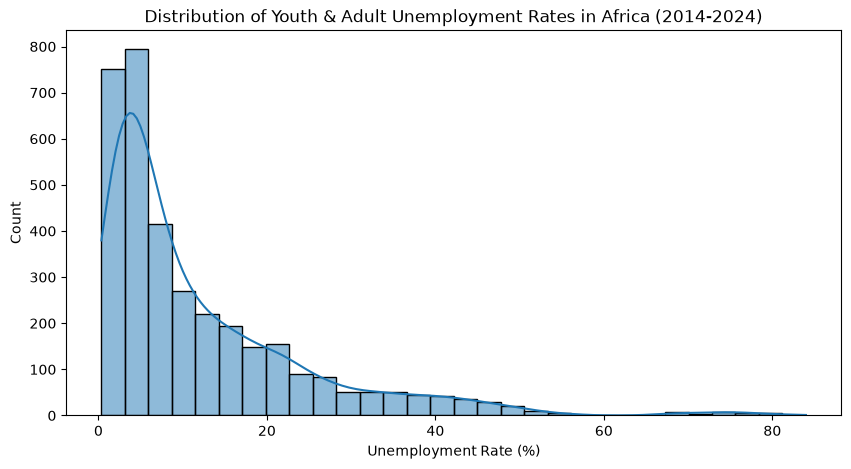

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df_long["unemployment_rate"], bins=30, kde=True)
plt.title("Distribution of Youth & Adult Unemployment Rates in Africa (2014-2024)")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")
plt.show()

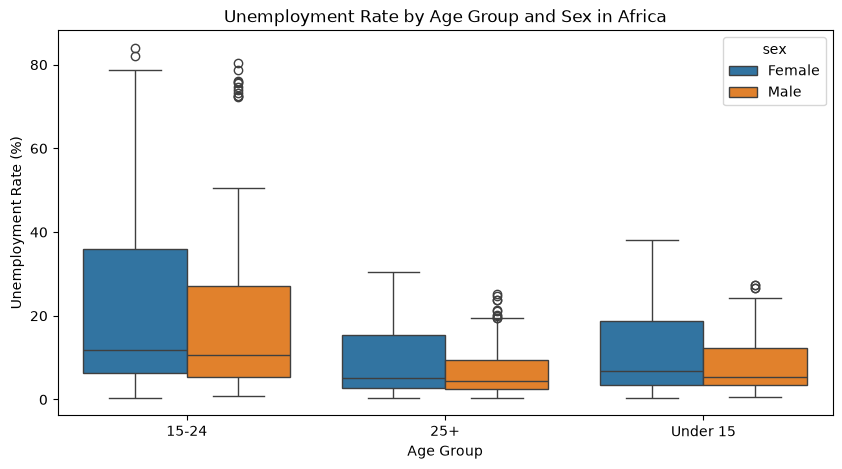

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_long, x="age_group", y="unemployment_rate", hue="sex")
plt.title("Unemployment Rate by Age Group and Sex in Africa")
plt.xlabel("Age Group")
plt.ylabel("Unemployment Rate (%)")
plt.show()

In [12]:
df_encoded = df_long.copy()

df_encoded["sex_encoded"] = df_encoded["sex"].map({"Male": 0, "Female": 1})
df_encoded["age_group_encoded"] = df_encoded["age_group"].map({"Under 15": 0, "15-24": 1, "25+": 2})

country_dummies = pd.get_dummies(df_encoded["country_name"], prefix="country", drop_first=True)
df_encoded = pd.concat([df_encoded, country_dummies], axis=1)

df_encoded.head()

,country_name,sex,age_group,age_categories,year,unemployment_rate,sex_encoded,age_group_encoded,country_Angola,country_Benin,...,country_Somalia,country_South Africa,country_South Sudan,country_Sudan,"country_Tanzania, United Republic of",country_Togo,country_Tunisia,country_Uganda,country_Zambia,country_Zimbabwe
0,Algeria,Female,15-24,Youth,2014,39.169,1,1,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Algeria,Female,25+,Adults,2014,11.913,1,2,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Algeria,Female,Under 15,Children,2014,15.687,1,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Algeria,Male,15-24,Youth,2014,22.742,0,1,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Algeria,Male,25+,Adults,2014,6.491,0,2,False,False,...,False,False,False,False,False,False,False,False,False,False


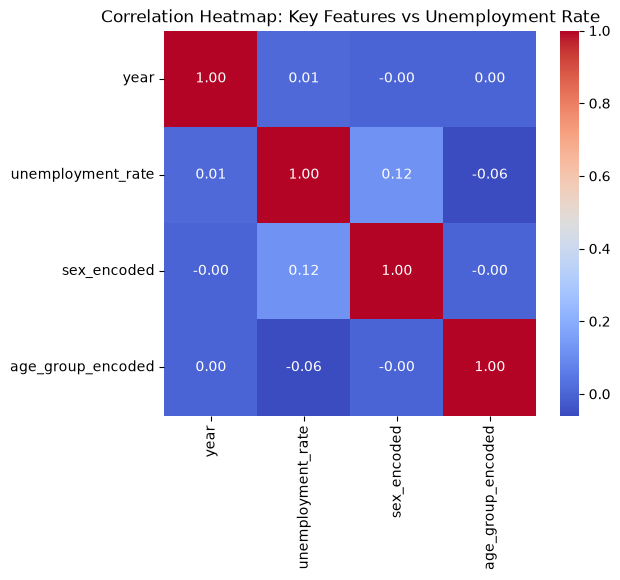

In [14]:
correlation_columns = ["year", "unemployment_rate", "sex_encoded", "age_group_encoded"]

plt.figure(figsize=(6, 5))
sns.heatmap(df_encoded[correlation_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Key Features vs Unemployment Rate")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_columns = [col for col in df_encoded.columns if col.startswith("country_") and col != "country_name"] + ["year", "sex_encoded", "age_group_encoded"]

X = df_encoded[feature_columns]
y = df_encoded["unemployment_rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", X_train_scaled.shape)
print("Testing rows:", X_test_scaled.shape)

Training rows: (2798, 55)
Testing rows: (700, 55)


In [17]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MSE:", mse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression MSE: 62.546053081368136
Linear Regression R2: 0.6447577379703726


In [18]:
sgd_model = SGDRegressor(max_iter=1000, learning_rate="invscaling", eta0=0.01, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

y_pred_sgd = sgd_model.predict(X_test_scaled)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print("SGD Regressor MSE:", mse_sgd)
print("SGD Regressor R2:", r2_sgd)

SGD Regressor MSE: 63.88478613963265
SGD Regressor R2: 0.6371541477125984


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MSE: 5.580491150998998
Random Forest R2: 0.9683045339865298


In [21]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree MSE:", mse_dt)
print("Decision Tree R2:", r2_dt)

Decision Tree MSE: 1.7685277942857147
Decision Tree R2: 0.9899553083983252


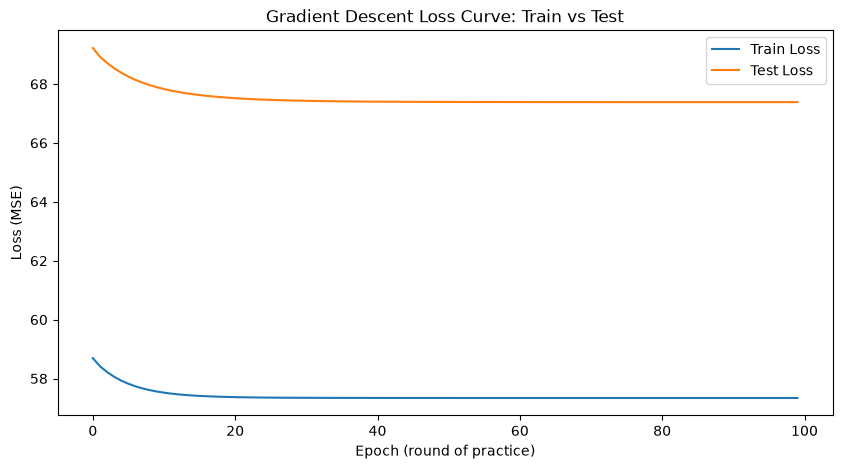

In [22]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

sgd_loss_model = SGDRegressor(learning_rate="invscaling", eta0=0.01, random_state=42, warm_start=True, max_iter=1)

train_losses = []
test_losses = []
n_epochs = 100

for epoch in range(n_epochs):
    sgd_loss_model.fit(X_train_scaled, y_train)
    train_pred = sgd_loss_model.predict(X_train_scaled)
    test_pred = sgd_loss_model.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(10, 5))
plt.plot(range(n_epochs), train_losses, label="Train Loss")
plt.plot(range(n_epochs), test_losses, label="Test Loss")
plt.xlabel("Epoch (round of practice)")
plt.ylabel("Loss (MSE)")
plt.title("Gradient Descent Loss Curve: Train vs Test")
plt.legend()
plt.show()

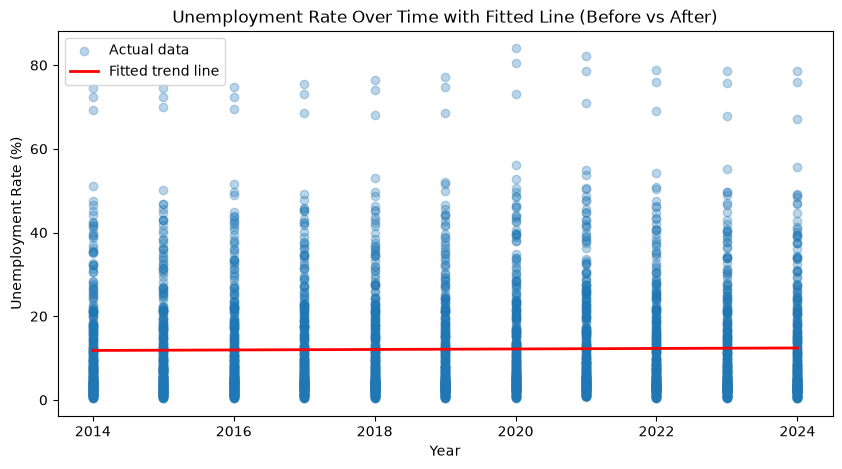

In [23]:
plt.figure(figsize=(10, 5))
plt.scatter(df_encoded["year"], df_encoded["unemployment_rate"], alpha=0.3, label="Actual data")

import numpy as np
years_sorted = np.sort(df_encoded["year"].unique())
avg_by_year = df_encoded.groupby("year")["unemployment_rate"].mean()
z = np.polyfit(years_sorted, avg_by_year.values, 1)
line_values = np.poly1d(z)(years_sorted)

plt.plot(years_sorted, line_values, color="red", linewidth=2, label="Fitted trend line")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time with Fitted Line (Before vs After)")
plt.legend()
plt.show()

In [24]:
import joblib

joblib.dump(rf_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

print("Model, scaler, and feature list saved!")

Model, scaler, and feature list saved!


In [25]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'best_model.pkl', 'feature_columns.pkl', 'global_unemployment_data.csv', 'multivariate.ipynb', 'scaler.pkl']


In [26]:
importances = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.head(10))

                 feature  importance
54     age_group_encoded    0.231235
12      country_Djibouti    0.098691
27         country_Libya    0.056916
53           sex_encoded    0.054612
43  country_South Africa    0.053789
16      country_Eswatini    0.047020
10         country_Congo    0.037429
2       country_Botswana    0.037212
35       country_Namibia    0.037142
18         country_Gabon    0.034360


In [27]:
def predict_unemployment(country, sex, age_group, year):
    input_data = pd.DataFrame(0, index=[0], columns=feature_columns)
    input_data["year"] = year
    input_data["sex_encoded"] = 1 if sex == "Female" else 0
    age_map = {"Under 15": 0, "15-24": 1, "25+": 2}
    input_data["age_group_encoded"] = age_map[age_group]

    country_col = f"country_{country}"
    if country_col in input_data.columns:
        input_data[country_col] = 1

    input_scaled = scaler.transform(input_data)
    prediction = rf_model.predict(input_scaled)
    return prediction[0]

sample_prediction = predict_unemployment("Kenya", "Female", "15-24", 2024)
print("Predicted unemployment rate:", sample_prediction)

Predicted unemployment rate: 17.857130000000023


## Model Selection

I compared four regression approaches: Stochastic Gradient Descent (SGD) Linear Regression, standard scikit-learn Linear Regression, Random Forest, and Decision Tree.

- Linear Regression (MSE 62.5, R² 0.64) and SGD (MSE 63.9, R² 0.64) performed similarly, since both attempt to fit a straight-line relationship. Their moderate performance reflects the fact that the relationship between the features (country, sex, age group, year) and unemployment rate is not purely linear.
- Decision Tree (MSE 1.8, R² 0.99) scored the highest on the test set, but a single decision tree is prone to overfitting, since it can memorize the training data very closely without a safeguard against noise.
- Random Forest (MSE 5.6, R² 0.97) performed nearly as well as the Decision Tree, but is more trustworthy since it averages predictions across 100 individual trees, making it less likely to overfit and more likely to generalize well to new, unseen data.

I selected Random Forest as the best-performing model because it offers the best balance between strong predictive accuracy and generalization reliability, avoiding the overfitting risk of a single Decision Tree while still capturing the non-linear patterns in the data far better than either linear approach.